In [1]:
import pandas as pd
import numpy as np

In [2]:
sales = pd.read_csv("../data/m5-forecasting-accuracy/sales_train_validation.csv", nrows=1000)
calendar = pd.read_csv("../data/m5-forecasting-accuracy/calendar.csv")
prices = pd.read_csv("../data/m5-forecasting-accuracy/sell_prices.csv")

In [3]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [4]:
sales.shape

(1000, 1919)

In [5]:
sales.columns[:10]

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4'],
      dtype='object')

In [6]:
sales.isnull().sum().head()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
dtype: int64

In [7]:
sales.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.84900,0.771000,0.643000,0.602000,0.427000,0.693000,0.565000,1.178000,0.7150,0.575000,...,0.932000,1.493000,1.472000,1.11300,1.004000,0.884000,0.883000,1.089000,1.403000,1.504000
std,3.37455,3.443605,3.128472,2.308013,1.699282,3.358278,1.948222,4.603423,2.5769,2.538665,...,1.993326,3.451937,3.273826,2.65052,2.041115,1.960711,1.985259,2.128288,2.515337,2.928577
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,1.000000,2.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,54.00000,73.000000,67.000000,33.000000,29.000000,74.000000,26.000000,78.000000,30.0000,36.000000,...,22.000000,49.000000,44.000000,37.00000,28.000000,28.000000,24.000000,20.000000,23.000000,35.000000


<Axes: title={'center': 'Sales Trend for One Product'}>

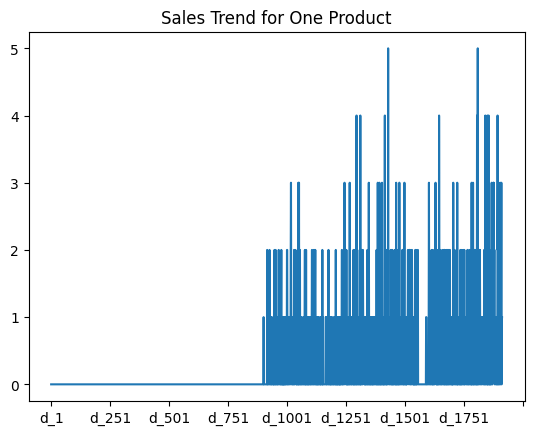

In [8]:
item = sales.iloc[0, 6:]   # skip metadata columns
item.plot(title="Sales Trend for One Product")

In [9]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [10]:
calendar[['date','event_name_1']].head()

,date,event_name_1
0,2011-01-29,NaN
1,2011-01-30,NaN
2,2011-01-31,NaN
3,2011-02-01,NaN
4,2011-02-02,NaN


In [11]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [12]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


In [13]:
sales.isnull().sum()
calendar.isnull().sum()
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [14]:
sales.dtypes
calendar.dtypes
prices.dtypes

store_id       object
item_id        object
wm_yr_wk        int64
sell_price    float64
dtype: object

In [15]:
calendar['date'] = pd.to_datetime(calendar['date'])

In [16]:
sales.duplicated().sum()

np.int64(0)

In [17]:
def load_data():
    sales = pd.read_csv("../data/m5-forecasting-accuracy/sales_train_validation.csv", nrows=1000)
    calendar = pd.read_csv("../data/m5-forecasting-accuracy/calendar.csv")
    prices = pd.read_csv("../data/m5-forecasting-accuracy/sell_prices.csv")
    return sales, calendar, prices

In [18]:
sales.isnull().sum().head()
calendar.isnull().sum().head()
prices.isnull().sum().head()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [19]:
calendar.fillna("None", inplace=True)

In [21]:
prices.ffill(inplace=True)

In [22]:
prices.bfill(inplace=True)

In [23]:
sales.fillna(0, inplace=True)

In [24]:
sales.dtypes
calendar.dtypes
prices.dtypes

store_id       object
item_id        object
wm_yr_wk        int64
sell_price    float64
dtype: object

In [25]:
calendar['date'] = pd.to_datetime(calendar['date'])

In [26]:
sales.duplicated().sum()
calendar.duplicated().sum()
prices.duplicated().sum()

np.int64(0)

In [27]:
sales.drop_duplicates(inplace=True)
calendar.drop_duplicates(inplace=True)
prices.drop_duplicates(inplace=True)

In [29]:
sales.shape
calendar.shape
prices.shape

(6841121, 4)

In [30]:
import sys
sys.path.append("../src")

In [31]:
from pipeline import run_pipeline

In [32]:
sales, calendar, prices = run_pipeline()